In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
# Load MNIST dataset
(X_train, y_train), _ = tf.keras.datasets.mnist.load_data()

# Filter only 0 and 1
mask = (y_train == 0) | (y_train == 1)
X = X_train[mask]
y = y_train[mask]

# Normalize and reshape
X = X / 255.0
X = X.reshape(X.shape[0], -1)   # flatten to (m, 784)

# Reduce to 400 features to match your assignment
X = X[:, :400]

y = y.reshape(-1, 1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape of X: (12665, 400)
Shape of y: (12665, 1)


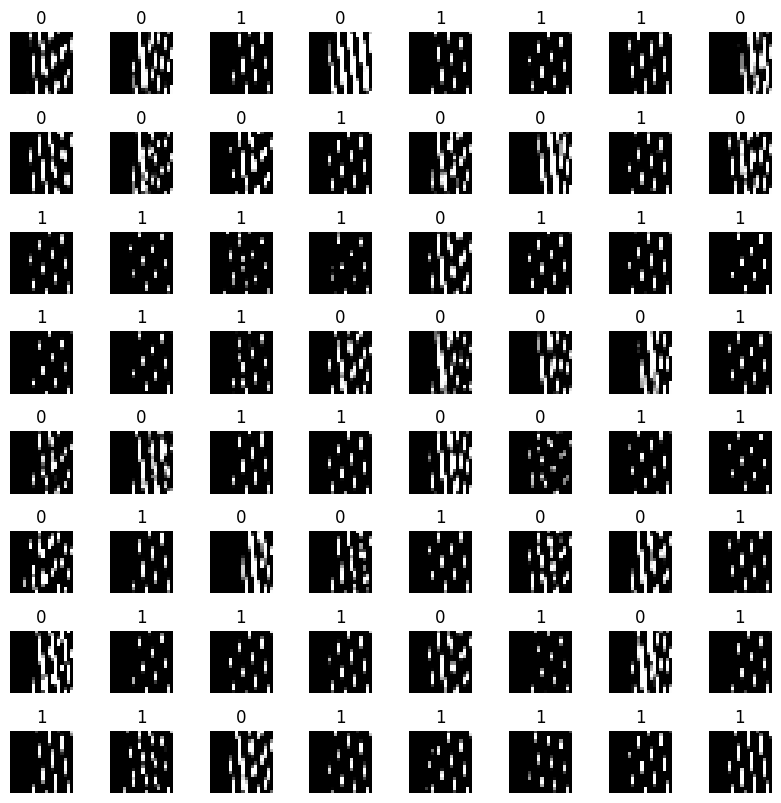

In [3]:
m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1)

for i, ax in enumerate(axes.flat):
    idx = np.random.randint(m)
    img = X[idx].reshape(20,20).T
    ax.imshow(img, cmap='gray')
    ax.set_title(y[idx,0])
    ax.axis('off')

plt.show()

In [4]:
model = Sequential([
    tf.keras.Input(shape=(400,)),
    Dense(25, activation='sigmoid'),
    Dense(15, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 25)             │        10,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,431 (40.75 KB)

 Trainable params: 10,431 (40.75 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001),
)

model.fit(X, y, epochs=20, verbose=1)

Epoch 1/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2794
Epoch 2/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0443
Epoch 3/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0234
Epoch 4/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0162
Epoch 5/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0122
Epoch 6/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0097
Epoch 7/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0079
Epoch 8/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0066
Epoch 9/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0056
Epoch 10/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0049
Epoch 11/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0039
Epoch 12/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0034
Epoch 13/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0030
Epoch 14/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0024
Epoch 15/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [6]:
# Example predictions
pred0 = model.predict(X[0].reshape(1,400))
pred1 = model.predict(X[10].reshape(1,400))

print("Prediction for sample 0:", pred0)
print("Prediction for sample 10:", pred1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction for sample 0: [[0.00010475]]
Prediction for sample 10: [[0.9998551]]


In [7]:
prediction = pred1

yhat = 1 if prediction >= 0.5 else 0
print("Final prediction:", yhat)

Final prediction: 1


In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [9]:
def my_dense(a_in, W, b, g):
    units = W.shape[1]
    a_out = np.zeros(units)

    for j in range(units):
        z = np.dot(a_in, W[:, j]) + b[j]
        a_out[j] = g(z)

    return a_out

In [10]:
def my_sequential(x, W1, b1, W2, b2, W3, b3):
    a1 = my_dense(x, W1, b1, sigmoid)
    a2 = my_dense(a1, W2, b2, sigmoid)
    a3 = my_dense(a2, W3, b3, sigmoid)
    return a3

In [11]:
layer1, layer2, layer3 = model.layers

W1, b1 = layer1.get_weights()
W2, b2 = layer2.get_weights()
W3, b3 = layer3.get_weights()

In [12]:
pred = my_sequential(X[0], W1, b1, W2, b2, W3, b3)

yhat = 1 if pred >= 0.5 else 0

print("Prediction:", yhat)
print("Actual:", y[0,0])

Prediction: 0
Actual: 0


In [13]:
def my_dense_v(A_in, W, b, g):
    Z = np.matmul(A_in, W) + b
    A_out = g(Z)
    return A_out

def my_sequential_v(X, W1, b1, W2, b2, W3, b3):
    A1 = my_dense_v(X, W1, b1, sigmoid)
    A2 = my_dense_v(A1, W2, b2, sigmoid)
    A3 = my_dense_v(A2, W3, b3, sigmoid)
    return A3

Prediction = my_sequential_v(X, W1, b1, W2, b2, W3, b3)
Yhat = (Prediction >= 0.5).astype(int)

print("First prediction:", Yhat[0])

First prediction: [0]
